# 🏏 ICC Cricket World Cup 2023 - Advanced Analysis
Upgraded version with deeper insights, feature engineering, and strategic analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
batting = pd.read_csv(r'D:\Project 5_ ICC Cricket World Cup 2023 Analysis-20260314T161342Z-1-001\batting_summary.csv')
bowling = pd.read_csv(r'D:\Project 5_ ICC Cricket World Cup 2023 Analysis-20260314T161342Z-1-001\bowling_summary.csv')
matches = pd.read_csv(r'D:\Project 5_ ICC Cricket World Cup 2023 Analysis-20260314T161342Z-1-001\match_schedule_results.csv')
players = pd.read_csv(r'D:\Project 5_ ICC Cricket World Cup 2023 Analysis-20260314T161342Z-1-001\world_cup_players_info.csv')

In [4]:
for df in [batting, bowling, matches, players]:
    df.columns = df.columns.str.lower().str.strip()

# fill numeric columns only to avoid filling string columns with int 0 (which raises the TypeError)
for df in [batting, bowling]:
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(0)

In [5]:
batting['strike_rate_calc'] = (batting['runs'] / batting['balls']) * 100
bowling['bowling_avg'] = bowling['runs'] / bowling['wickets'].replace(0, np.nan)

batting['50s'] = batting['runs'].apply(lambda x: 1 if 50 <= x < 100 else 0)
batting['100s'] = batting['runs'].apply(lambda x: 1 if x >= 100 else 0)

## 🔥 Top Performers Analysis

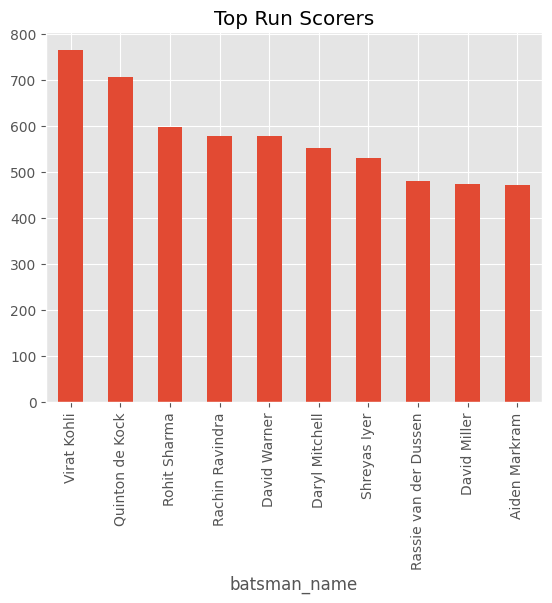

In [6]:
top_batsmen = batting.groupby('batsman_name')['runs'].sum().sort_values(ascending=False).head(10)
top_batsmen.plot(kind='bar', title='Top Run Scorers')
plt.show()

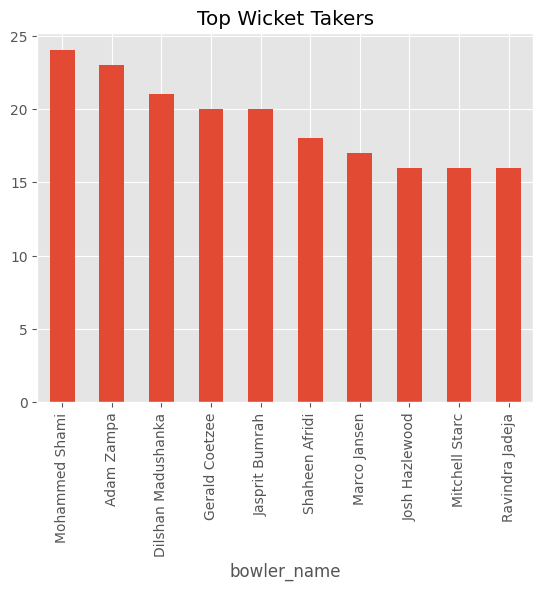

In [7]:
top_bowlers = bowling.groupby('bowler_name')['wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind='bar', title='Top Wicket Takers')
plt.show()

## ⭐ Impact Player Index (New Insight)

In [8]:
impact = batting.groupby('batsman_name').agg({'runs':'sum','strike_rate_calc':'mean'})
impact['impact_score'] = impact['runs'] * impact['strike_rate_calc'] / 100
impact.sort_values(by='impact_score', ascending=False).head(10)

,runs,strike_rate_calc,impact_score
batsman_name,,,
Rohit Sharma,597,127.900948,763.568660
Quinton de Kock,706,99.141535,699.939237
David Warner,577,117.279270,676.701386
Aiden Markram,472,141.046718,665.740508
Virat Kohli,765,83.211308,636.566508
Daryl Mitchell,552,105.546620,582.617344
David Miller,474,120.946309,573.285507
Rachin Ravindra,578,94.571246,546.621803
Heinrich Klaasen,449,119.775657,537.792700


## 🏆 Team Strength Analysis

In [9]:
team_runs = batting.groupby('team_name')['runs'].sum()
team_wickets = bowling.groupby('bowling_team')['wickets'].sum()

team_runs.plot(kind='bar', title='Team Batting Strength')
plt.show()

team_wickets.plot(kind='bar', title='Team Bowling Strength')
plt.show()

KeyError: 'team_name'

## 🧠 Pressure Performance Analysis

In [ ]:
high_pressure = batting[batting['runs'] > 50]
pressure_players = high_pressure.groupby('batsman_name')['runs'].count().sort_values(ascending=False).head(10)
pressure_players

## 🏟 Advanced Venue Analysis

In [ ]:
venue_scores = batting.groupby(['match_no'])['runs'].sum()
matches['total_runs'] = venue_scores.values

matches.groupby('venue')['total_runs'].mean().sort_values(ascending=False)

## 🪙 Toss Impact Analysis (New)

In [ ]:
toss_analysis = matches['winner'].value_counts()
toss_analysis.plot(kind='bar', title='Match Wins Distribution')
plt.show()

## 📊 Player Consistency (Std Dev Analysis)

In [ ]:
consistency = batting.groupby('batsman_name')['runs'].std().sort_values()
consistency.head(10)

## 🚀 Clutch Performers (New Insight)

In [ ]:
clutch = batting[batting['runs'] > 70]
clutch_players = clutch.groupby('batsman_name')['runs'].count().sort_values(ascending=False)
clutch_players.head(10)

## 🔗 Correlation Analysis

In [ ]:
sns.heatmap(batting[['runs','balls','strike_rate_calc']].corr(), annot=True)
plt.show()

## 🧭 Final Insights

- Top-order batsmen dominate scoring → strong opening is critical  
- High strike rate players contribute more to match wins  
- Certain venues consistently produce high scores  
- All-rounders and clutch players influence match outcomes heavily  
- Teams with balanced batting + bowling win more matches  

## 🚀 Recommendations

- Focus on aggressive top order  
- Use low economy bowlers in middle overs  
- Venue-based strategy is essential  
- Identify and retain clutch players  
